# Linear Regression Model

## Objective

The objective of this notebook is to build a Linear Regression model that predicts loan amount based on a borrower's annual income.

The model is evaluated using:

- Coefficient
- Intercept
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics assess how well annual income predicts loan amount.

In [1]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# LOAD DATASET

df = pd.read_csv("clean_loanset1.csv")

In [3]:
# SELECT FEATURES

X = df[["consolidated_annual_income"]]

y = df["loan_amount"]

In [4]:
# SPLIT DATASET

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [5]:
# TRAIN MODEL

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
# MODEL COEFFECIENT

print("Slope (Coefficient):", model.coef_[0])

print("Intercept:", model.intercept_)

Slope (Coefficient): 0.060407044931361925
Intercept: 10972.771759723051


In [7]:
# PREDICT LOAN AMOUNT

y_pred = model.predict(X_test)

In [8]:
# MODEL EVALUATION

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", round(mae,2))

print("Mean Squared Error  :", round(mse,2))

print("Root Mean Squared Error:", round(rmse,2))

print("R² Score:", round(r2,3))

Mean Absolute Error : 7588.61
Mean Squared Error  : 93678975.94
Root Mean Squared Error: 9678.79
R² Score: 0.111


In [9]:
# ACTUAL VS PREDICTED VALUES

results = pd.DataFrame({
    "Actual Loan": y_test,
    "Predicted Loan": y_pred
})

results.head(10)

,Actual Loan,Predicted Loan
6252,10000,14899.229680
4684,14400,13207.832422
1731,1200,14597.194456
4742,40000,17043.679775
4521,7500,14536.787411
6340,6500,20033.828499
576,5000,12314.533042
5202,3000,12712.494654
6363,12600,14597.194456
439,13000,14657.601501


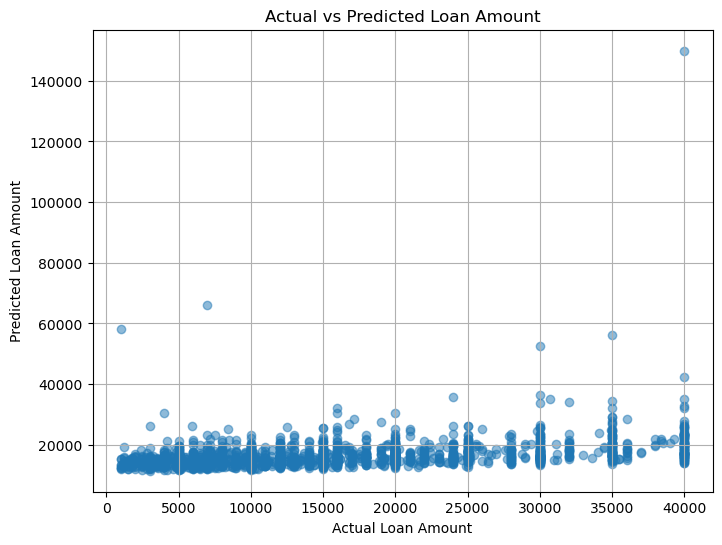

In [10]:
# SCATTER PLOT

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Loan Amount")

plt.ylabel("Predicted Loan Amount")

plt.title("Actual vs Predicted Loan Amount")

plt.grid(True)

plt.show()

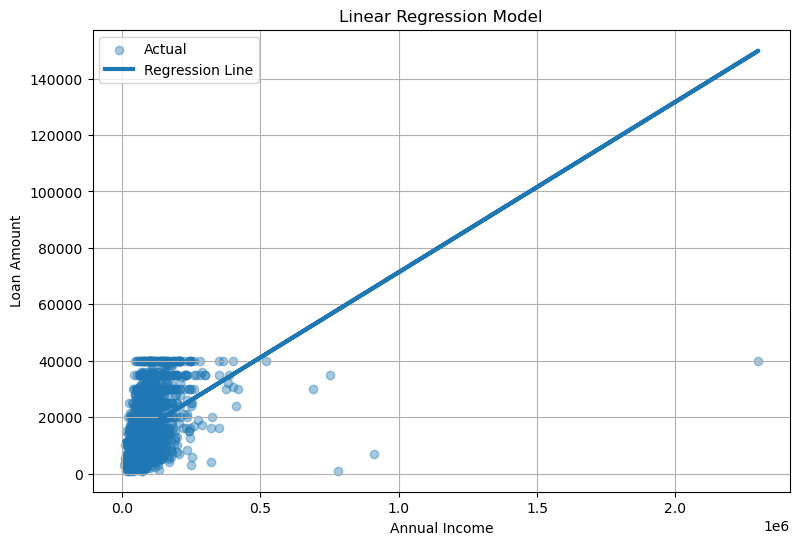

In [11]:
# REGRESSION LINE

plt.figure(figsize=(9,6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.4,
    label="Actual"
)

plt.plot(
    X_test,
    y_pred,
    linewidth=3,
    label="Regression Line"
)

plt.xlabel("Annual Income")

plt.ylabel("Loan Amount")

plt.title("Linear Regression Model")

plt.legend()

plt.grid(True)

plt.show()

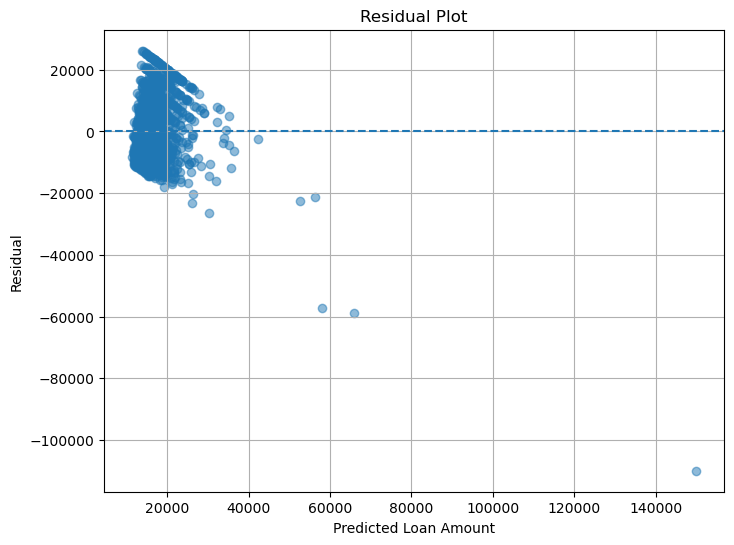

In [12]:
# RESIDUAL ANALYSIS

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Loan Amount")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [13]:
# FEATURE IMPORTANCE

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef

,Feature,Coefficient
0,consolidated_annual_income,0.060407


## Interpretation

### Coefficient

The coefficient indicates the average change in loan amount associated with a one-unit increase in annual income.

A positive coefficient suggests that borrowers with higher annual incomes generally receive larger loans.

---

### R² Score

The model produced an R² score of approximately **0.145**.

This indicates that annual income explains about **14.5%** of the variation in loan amounts.

The remaining variation is influenced by additional borrower characteristics such as:

- Interest rate
- Debt-to-income ratio
- Loan purpose
- Credit history
- Employment characteristics

---

### Error Metrics

MAE measures the average prediction error.

RMSE provides the typical size of prediction errors while giving greater weight to larger errors.

Lower values indicate better predictive performance.

# Business Insight

Annual income has a positive relationship with loan amount but is not sufficient by itself to accurately predict lending decisions.

The relatively low R² value indicates that lenders rely on multiple borrower characteristics rather than income alone.

Future predictive models should incorporate additional financial and credit-related variables to improve prediction accuracy.

# Conclusion

The Linear Regression model demonstrates that borrower income is a statistically meaningful predictor of loan amount.

However, because annual income explains only a limited proportion of the variation in loan size, additional borrower attributes should be included in predictive models to better reflect lending decisions.

The model serves as a useful baseline for comparison with more advanced models such as Logistic Regression and Random Forest.